# Turkish Hazelnut — Event Triggers → Production & Price

**Question**: How much do frost, hail, drought, and lira depreciation explain annual production and crop-year price?

**Unit of analysis**: one row = one harvest year (e.g. 2020 = crop harvested Aug–Sep 2020).

---
### Features
| Feature | Description | Source | Season |
|---|---|---|---|
| `april_dh` | Frost degree-hours, Apr 1–30, threshold −1.5 °C, production-weighted across 7 provinces | ERA5 hourly t2m | Spring |
| `march_dh` | Frost degree-hours, Mar 15–31, threshold −3.0 °C, production-weighted | ERA5 hourly t2m | Spring |
| `hail_cp_max` | Max 6-hr convective precip across provinces, Jun–Aug (mm) — ERA5 hail proxy | ERA5 hourly cp | Summer |
| `spei_aug` | SPEI-03 in August = 3-month moisture index (Jun–Aug). Negative = drought | ERA5-derived | Summer |
| `lira_depr` | Annual TRY/USD depreciation rate (e.g. −0.44 = TRY lost 44 %) | Yahoo Finance | Annual |

### Targets
| Target | Description | Source | Period |
|---|---|---|---|
| `production_fao` | Turkey hazelnut production (MT) | FAOSTAT QCL item 225 | 1961–2024 |
| `production_tuik` | Turkey hazelnut production (MT) | TÜİK Nuts Balance Sheet | 2000–2024 |
| `price_usd_kg` | Giresun exchange spot price, USD/kg in-shell, crop-year mean (Sep–Aug) | Giresun Commodity Exchange | 2000–2022 |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

DATA = Path('../data/raw')

## 1. Load Data

In [2]:
# ── Production ─────────────────────────────────────────────────────────────────
fao  = pd.read_csv(DATA / 'faostat/turkey_hazelnut_production.csv',
                   index_col='year')['production_mt'].rename('production_fao')

tuik = pd.read_csv(DATA / 'tuik_hazelnut_balance.csv',
                   index_col='harvest_year')['production_mt'].rename('production_tuik')

# ── Weather triggers ───────────────────────────────────────────────────────────
frost = pd.read_csv(DATA / 'era5_frost_monthly.csv', index_col='year')[['march_dh', 'april_dh']]

hail  = pd.read_csv(DATA / 'era5_hail_monthly.csv', index_col='year')
hail['hail_cp_max'] = hail[['jun_cp_mm', 'jul_cp_mm', 'aug_cp_mm']].max(axis=1)
hail  = hail[['hail_cp_max']]

spei  = pd.read_csv(DATA / 'spei/spei03_era5.csv', index_col='year').rename(columns={'spei03': 'spei_aug'})

fx    = pd.read_csv(DATA / 'fx/tryusd_annual.csv', index_col='year')[['depreciation']].rename(
            columns={'depreciation': 'lira_depr'})

tmo_raw = pd.read_csv(DATA / 'hazelnut_35yr_master.csv', index_col=0)
tmo_raw.index.name = 'year'
tmo   = tmo_raw[['tmo_try_ret']].rename(columns={'tmo_try_ret': 'tmo_change'})

# ── Giresun crop-year price ────────────────────────────────────────────────────
monthly = pd.read_csv(DATA / 'giresun_spot_prices_monthly.csv')
# Exclude August open (opening bid of the *next* crop, not the current crop-year mean)
monthly = monthly[~((monthly['month'] == 8) & (monthly['period'] == 'open'))]
price   = (monthly.groupby('crop_year')['avg_usd_kg_inshell']
                  .mean()
                  .rename('price_usd_kg'))

print('FAOSTAT:',        fao.index.min(),  '–', fao.index.max(),  f'  n={fao.notna().sum()}')
print('TÜİK:',           tuik.index.min(), '–', tuik.index.max(), f'  n={tuik.notna().sum()}')
print('Frost/Hail:',     frost.index.min(),'–', frost.index.max())
print('SPEI:',           spei.index.min(), '–', spei.index.max())
print('Lira FX:',        fx.index.min(),   '–', fx.index.max())
print('TMO change:',     tmo.index.min(),  '–', tmo.index.max())
print('Giresun price:',  price.index.min(),'–', price.index.max(), f'  n={price.notna().sum()}')

FAOSTAT: 1961 – 2024   n=64
TÜİK: 2000 – 2024   n=25
Frost/Hail: 1990 – 2024
SPEI: 1950 – 2024
Lira FX: 2006 – 2025
TMO change: 1990 – 2024
Giresun price: 2000 – 2024   n=23


## 2. Feature Matrix

One row per harvest year. All features are observable *before* or *during* the harvest — not derived from production.

In [3]:
years = range(1990, 2025)
X_all = pd.DataFrame(index=years)
X_all.index.name = 'harvest_year'

X_all = X_all.join(frost).join(hail).join(spei).join(fx).join(tmo)
X_all = X_all.join(fao).join(tuik).join(price)

print('Feature matrix shape:', X_all.shape)
print('\nNon-null counts per column:')
print(X_all.notnull().sum().to_string())
print('\nSample rows:')
X_all[['march_dh','april_dh','hail_cp_max','spei_aug','lira_depr','tmo_change',
       'production_fao','production_tuik','price_usd_kg']].tail(10)

Feature matrix shape: (35, 9)

Non-null counts per column:
march_dh           35
april_dh           35
hail_cp_max        35
spei_aug           35
lira_depr          19
tmo_change         34
production_fao     35
production_tuik    25
price_usd_kg       23

Sample rows:


,march_dh,april_dh,hail_cp_max,spei_aug,lira_depr,tmo_change,production_fao,production_tuik,price_usd_kg
harvest_year,,,,,,,,,
2015,0.291,8.462,82.541,0.023,-0.205,0.123,646000.000,646000.000,3.969
2016,1.577,0.000,47.702,0.165,-0.170,0.129,420000.000,420000.000,3.806
2017,0.055,1.082,55.353,0.184,-0.069,0.114,675000.000,675000.000,2.854
2018,0.000,0.002,52.418,-0.822,-0.284,0.179,515000.000,515000.000,2.520
2019,0.302,0.129,64.463,0.361,-0.113,0.174,776046.000,776046.000,3.278
2020,2.381,0.000,61.390,-1.019,-0.193,0.148,665000.000,665000.000,3.229
2021,0.649,1.115,47.913,0.983,-0.445,0.226,684000.000,684000.000,2.658
2022,47.697,0.215,67.688,-0.724,-0.289,0.263,765000.000,765000.000,2.844
2023,2.776,0.000,73.280,0.083,-0.366,0.292,650000.000,650000.000,NaN


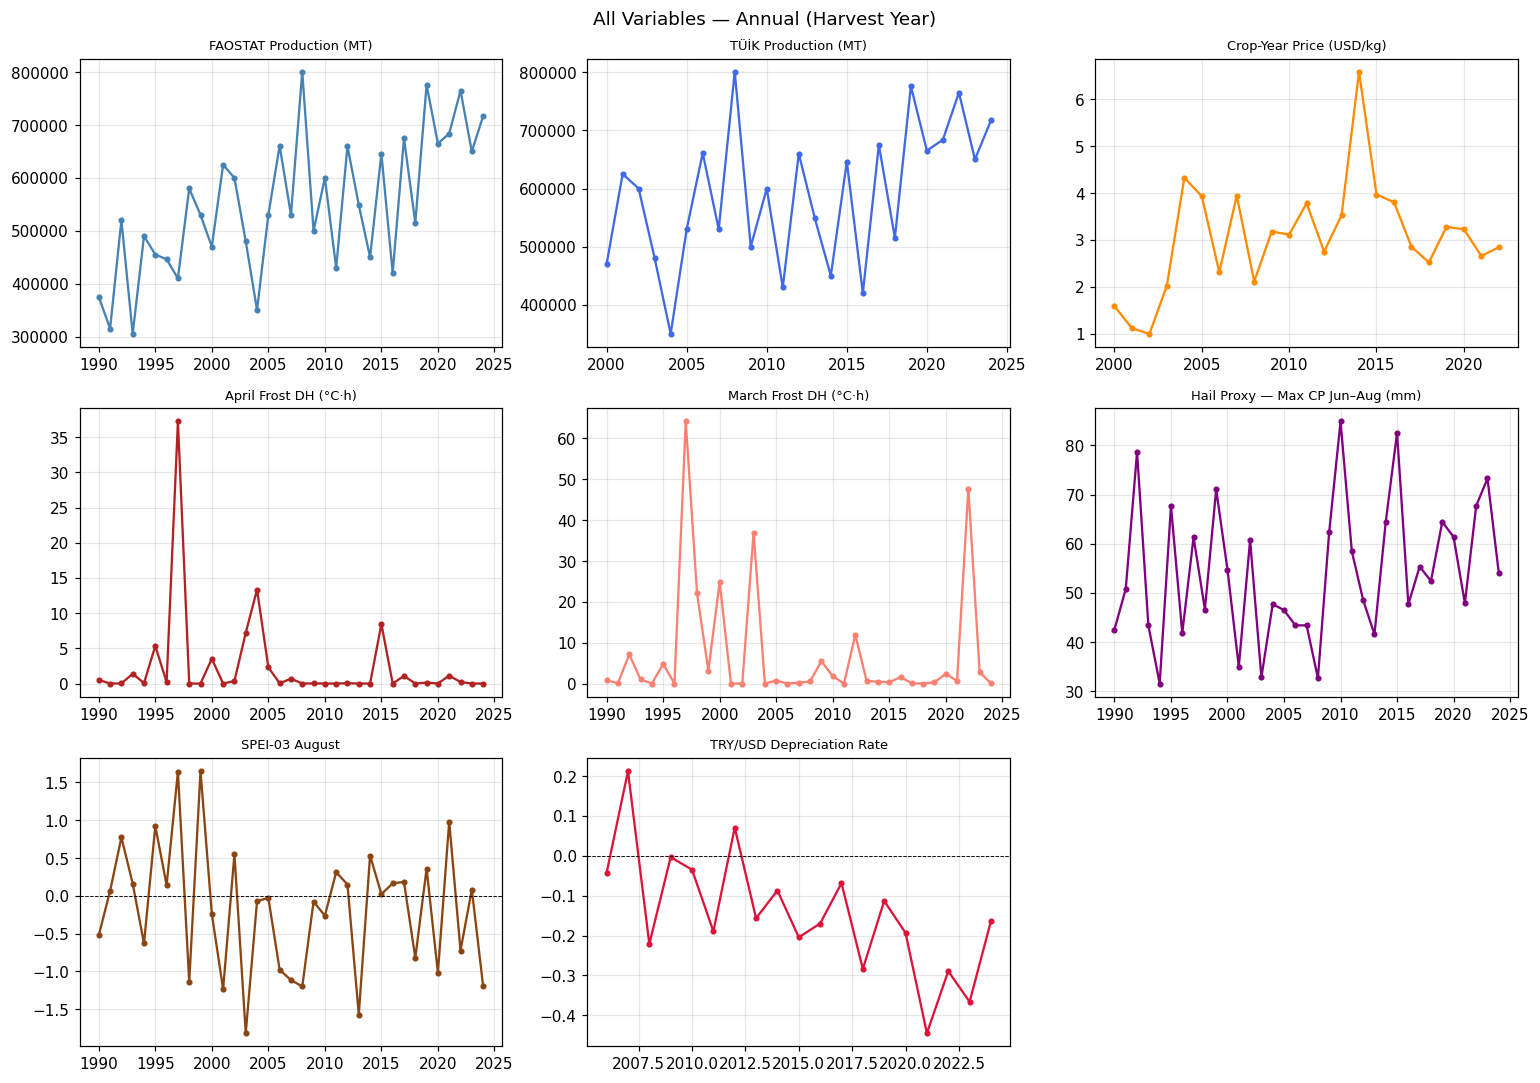

In [4]:
# ── Time series overview ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

series = [
    ('production_fao',  'FAOSTAT Production (MT)',          'steelblue'),
    ('production_tuik', 'TÜİK Production (MT)',             'royalblue'),
    ('price_usd_kg',    'Crop-Year Price (USD/kg)',          'darkorange'),
    ('april_dh',        'April Frost DH (°C·h)',            'firebrick'),
    ('march_dh',        'March Frost DH (°C·h)',            'salmon'),
    ('hail_cp_max',     'Hail Proxy — Max CP Jun–Aug (mm)', 'purple'),
    ('spei_aug',        'SPEI-03 August',                   'saddlebrown'),
    ('lira_depr',       'TRY/USD Depreciation Rate',        'crimson'),
    ('tmo_change',      'TMO Support Price Change (YoY)',    'darkgreen'),
]

for ax, (col, label, color) in zip(axes, series):
    s = X_all[col].dropna()
    ax.plot(s.index, s.values, color=color, lw=1.5, marker='o', ms=3)
    ax.set_title(label, fontsize=8.5)
    ax.grid(alpha=0.3)
    if col == 'spei_aug':
        ax.axhline(0, color='black', lw=0.6, ls='--')
    if col == 'lira_depr':
        ax.axhline(0, color='black', lw=0.6, ls='--')

axes[-1].set_visible(False)
plt.suptitle('All Variables — Annual (Harvest Year)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Model A — FAOSTAT Production

Target: `production_fao` (MT).  
We run two versions because lira data only starts 2006, which cuts the sample.

In [5]:
TRIGGERS_BASE = ['march_dh', 'april_dh', 'hail_cp_max', 'spei_aug', 'tmo_change']
TRIGGERS_LIRA = TRIGGERS_BASE + ['lira_depr']

def run_ols(df, features, target):
    """Fit OLS, print summary, return result object."""
    d = df[features + [target]].dropna()
    X = sm.add_constant(d[features])
    res = sm.OLS(d[target], X).fit()
    print(res.summary())
    print(f'\nSample: {d.index.min()}–{d.index.max()}   n = {len(d)}')
    return res, d

print('=== A1: FAOSTAT ~ frost + hail + SPEI (no lira) ===')
res_A1, d_A1 = run_ols(X_all, TRIGGERS_BASE, 'production_fao')

=== A1: FAOSTAT ~ frost + hail + SPEI (no lira) ===
                            OLS Regression Results                            
Dep. Variable:         production_fao   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     2.134
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0907
Time:                        13:43:14   Log-Likelihood:                -442.26
No. Observations:                  34   AIC:                             896.5
Df Residuals:                      28   BIC:                             905.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [6]:
print('=== A2: FAOSTAT ~ frost + hail + SPEI + lira ===')
res_A2, d_A2 = run_ols(X_all, TRIGGERS_LIRA, 'production_fao')

=== A2: FAOSTAT ~ frost + hail + SPEI + lira ===
                            OLS Regression Results                            
Dep. Variable:         production_fao   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                 -0.198
Method:                 Least Squares   F-statistic:                    0.5052
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.793
Time:                        13:43:14   Log-Likelihood:                -245.98
No. Observations:                  19   AIC:                             506.0
Df Residuals:                      12   BIC:                             512.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
c

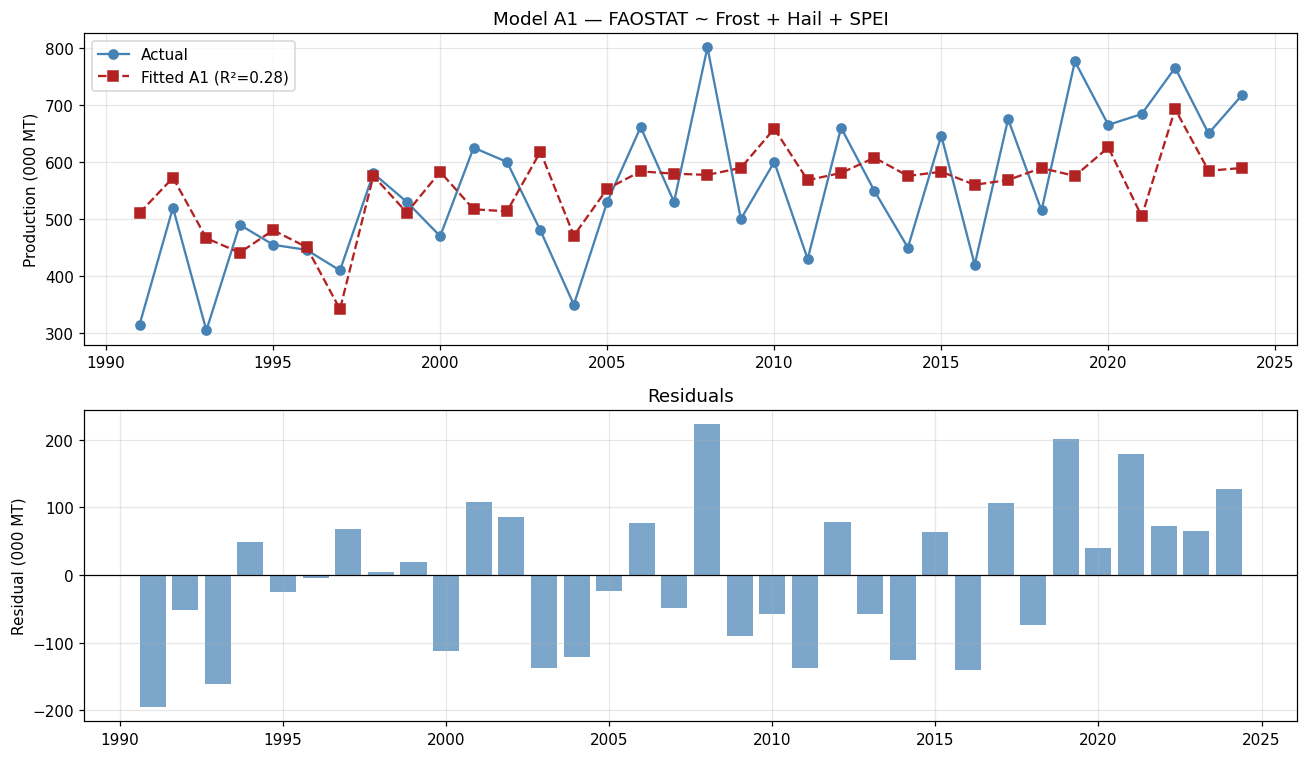

In [7]:
# Actual vs fitted + residuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

ax1.plot(d_A1.index, d_A1['production_fao'] / 1e3, 'o-', label='Actual', color='steelblue')
ax1.plot(d_A1.index, res_A1.fittedvalues / 1e3, 's--', label=f'Fitted A1 (R²={res_A1.rsquared:.2f})', color='firebrick')
ax1.set_ylabel('Production (000 MT)')
ax1.set_title('Model A1 — FAOSTAT ~ Frost + Hail + SPEI')
ax1.legend(); ax1.grid(alpha=0.3)

resid = d_A1['production_fao'] - res_A1.fittedvalues
ax2.bar(d_A1.index, resid / 1e3, color='steelblue', alpha=0.7)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Residual (000 MT)')
ax2.set_title('Residuals')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 4. Model B — TÜİK Production

Target: `production_tuik` (MT). Same features. Sample is shorter (2000–2024, n=25).

In [8]:
print('=== B1: TÜİK ~ frost + hail + SPEI (no lira) ===')
res_B1, d_B1 = run_ols(X_all, TRIGGERS_BASE, 'production_tuik')

=== B1: TÜİK ~ frost + hail + SPEI (no lira) ===
                            OLS Regression Results                            
Dep. Variable:        production_tuik   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.055
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.415
Time:                        13:43:14   Log-Likelihood:                -324.31
No. Observations:                  25   AIC:                             660.6
Df Residuals:                      19   BIC:                             667.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
c

In [9]:
print('=== B2: TÜİK ~ frost + hail + SPEI + lira ===')
res_B2, d_B2 = run_ols(X_all, TRIGGERS_LIRA, 'production_tuik')

=== B2: TÜİK ~ frost + hail + SPEI + lira ===
                            OLS Regression Results                            
Dep. Variable:        production_tuik   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                 -0.198
Method:                 Least Squares   F-statistic:                    0.5052
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.793
Time:                        13:43:14   Log-Likelihood:                -245.98
No. Observations:                  19   AIC:                             506.0
Df Residuals:                      12   BIC:                             512.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
cons

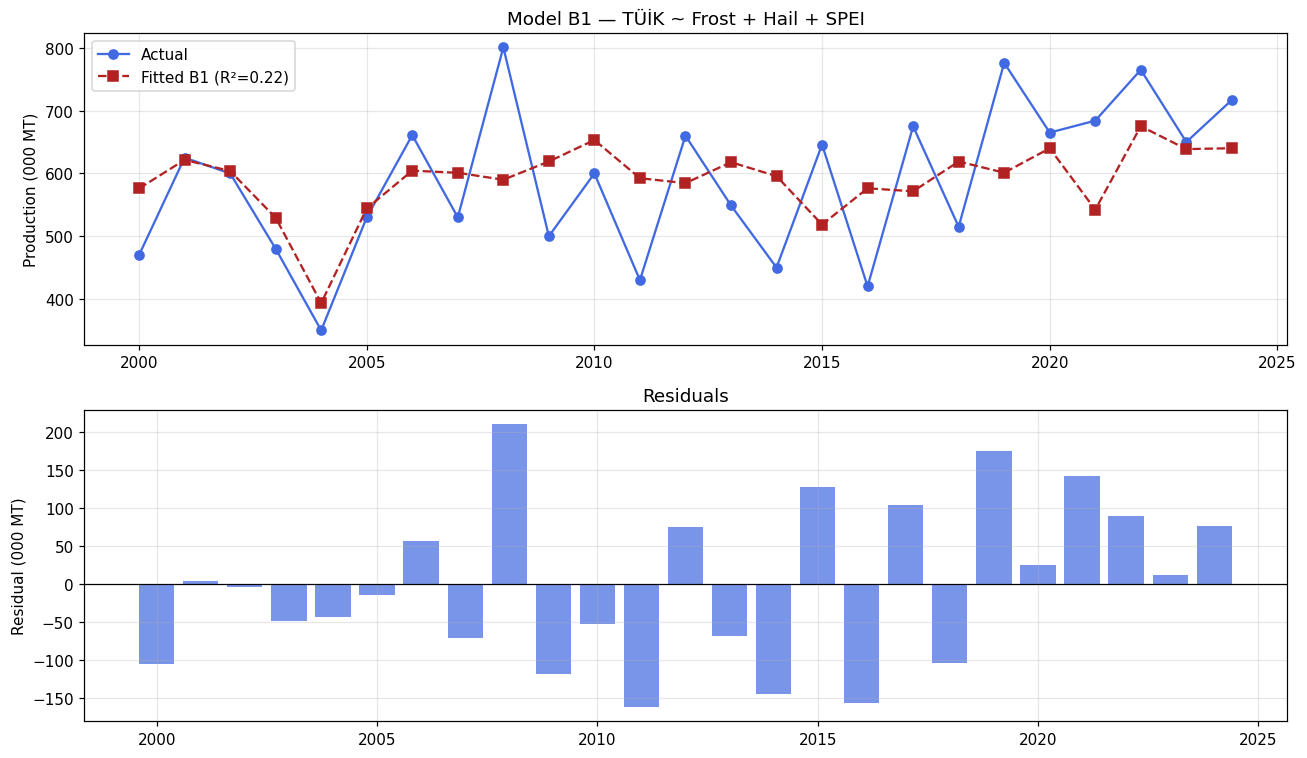

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

ax1.plot(d_B1.index, d_B1['production_tuik'] / 1e3, 'o-', label='Actual', color='royalblue')
ax1.plot(d_B1.index, res_B1.fittedvalues / 1e3, 's--', label=f'Fitted B1 (R²={res_B1.rsquared:.2f})', color='firebrick')
ax1.set_ylabel('Production (000 MT)')
ax1.set_title('Model B1 — TÜİK ~ Frost + Hail + SPEI')
ax1.legend(); ax1.grid(alpha=0.3)

resid = d_B1['production_tuik'] - res_B1.fittedvalues
ax2.bar(d_B1.index, resid / 1e3, color='royalblue', alpha=0.7)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Residual (000 MT)')
ax2.set_title('Residuals')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5. Model C — Crop-Year Price

Target: `price_usd_kg` — Giresun spot price, crop-year mean (Sep–Aug), USD/kg in-shell.  
Lira matters here: TRY depreciation compresses export prices in USD terms.

In [11]:
print('=== C1: Price ~ frost + hail + SPEI (no lira) ===')
res_C1, d_C1 = run_ols(X_all, TRIGGERS_BASE, 'price_usd_kg')

=== C1: Price ~ frost + hail + SPEI (no lira) ===
                            OLS Regression Results                            
Dep. Variable:           price_usd_kg   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     2.805
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0503
Time:                        13:43:15   Log-Likelihood:                -29.223
No. Observations:                  23   AIC:                             70.45
Df Residuals:                      17   BIC:                             77.26
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------


In [12]:
print('=== C2: Price ~ frost + hail + SPEI + lira ===')
res_C2, d_C2 = run_ols(X_all, TRIGGERS_LIRA, 'price_usd_kg')

=== C2: Price ~ frost + hail + SPEI + lira ===
                            OLS Regression Results                            
Dep. Variable:           price_usd_kg   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                 -0.228
Method:                 Least Squares   F-statistic:                    0.5048
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.792
Time:                        13:43:15   Log-Likelihood:                -21.558
No. Observations:                  17   AIC:                             57.12
Df Residuals:                      10   BIC:                             62.95
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
con

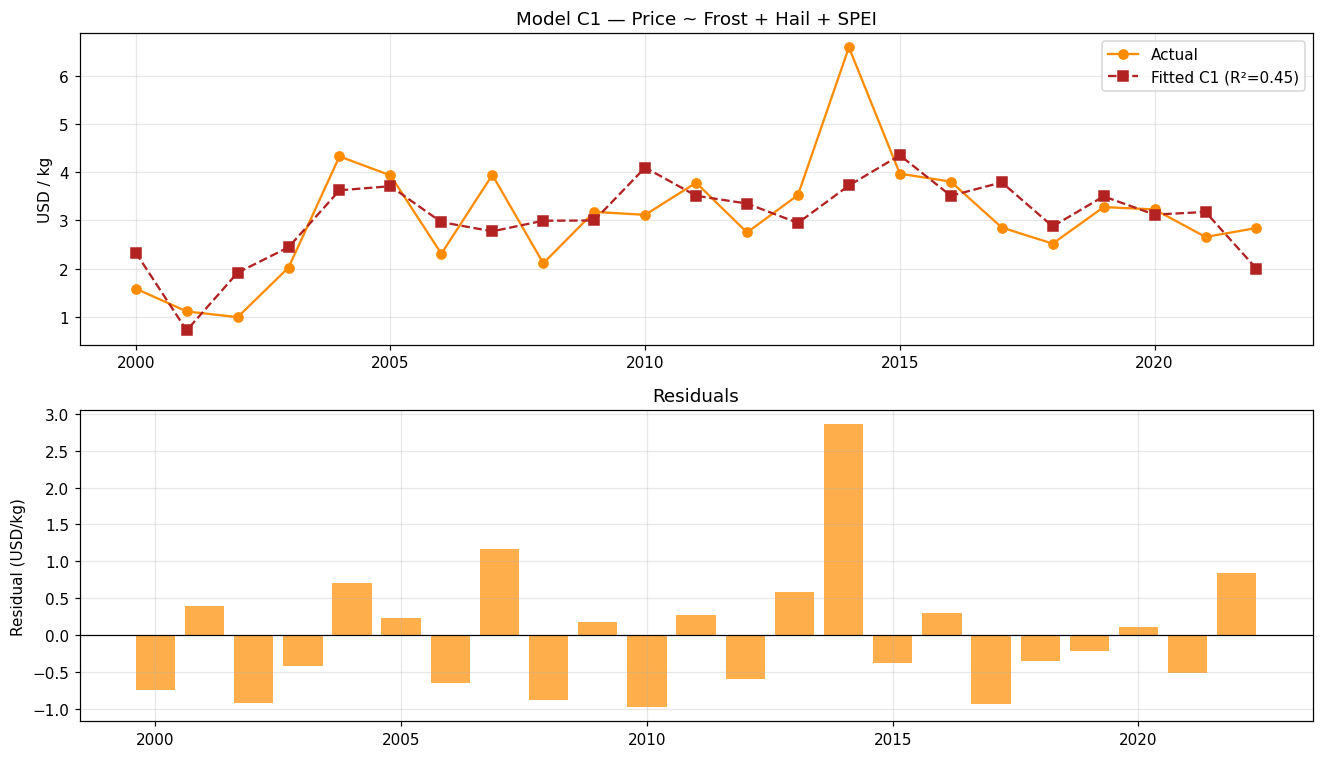

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

ax1.plot(d_C1.index, d_C1['price_usd_kg'], 'o-', label='Actual', color='darkorange')
ax1.plot(d_C1.index, res_C1.fittedvalues, 's--', label=f'Fitted C1 (R²={res_C1.rsquared:.2f})', color='firebrick')
ax1.set_ylabel('USD / kg')
ax1.set_title('Model C1 — Price ~ Frost + Hail + SPEI')
ax1.legend(); ax1.grid(alpha=0.3)

resid = d_C1['price_usd_kg'] - res_C1.fittedvalues
ax2.bar(d_C1.index, resid, color='darkorange', alpha=0.7)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Residual (USD/kg)')
ax2.set_title('Residuals')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6. Results Summary

In [14]:
MODELS = [
    ('A1', 'FAOSTAT ~ triggers',        res_A1, TRIGGERS_BASE),
    ('A2', 'FAOSTAT ~ triggers + lira', res_A2, TRIGGERS_LIRA),
    ('B1', 'TUK ~ triggers',            res_B1, TRIGGERS_BASE),
    ('B2', 'TUK ~ triggers + lira',     res_B2, TRIGGERS_LIRA),
    ('C1', 'Price ~ triggers',          res_C1, TRIGGERS_BASE),
    ('C2', 'Price ~ triggers + lira',   res_C2, TRIGGERS_LIRA),
]

def sig_stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

header = '{:<4} {:<32} {:>6} {:>7} {:>5}   {}'.format(
    'ID', 'Description', 'R2', 'AdjR2', 'n', 'Significant features (p<0.10)')
print(header)
print('-' * 100)
for name, desc, res, feats in MODELS:
    sig = [v + sig_stars(res.pvalues[v]) for v in feats if res.pvalues[v] < 0.10]
    row = '{:<4} {:<32} {:>6.3f} {:>7.3f} {:>5}   {}'.format(
        name, desc, res.rsquared, res.rsquared_adj, int(res.nobs),
        ', '.join(sig) if sig else 'none')
    print(row)

print('\n*** p<0.01  ** p<0.05  * p<0.10')


ID   Description                          R2   AdjR2     n   Significant features (p<0.10)
----------------------------------------------------------------------------------------------------
A1   FAOSTAT ~ triggers                0.276   0.147    34   none
A2   FAOSTAT ~ triggers + lira         0.202  -0.198    19   none
B1   TUK ~ triggers                    0.217   0.011    25   april_dh*
B2   TUK ~ triggers + lira             0.202  -0.198    19   none
C1   Price ~ triggers                  0.452   0.291    23   tmo_change**
C2   Price ~ triggers + lira           0.232  -0.228    17   none

*** p<0.01  ** p<0.05  * p<0.10


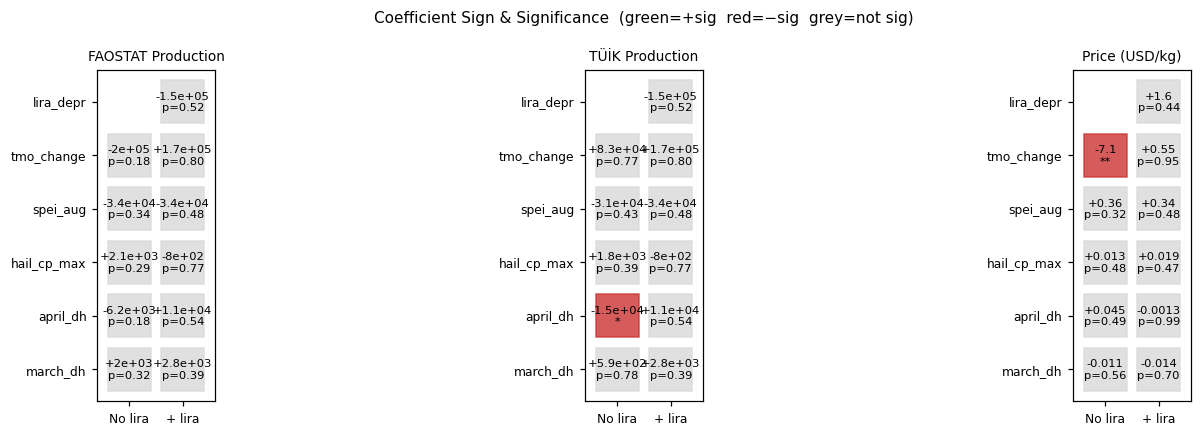

In [15]:
# ── Coefficient heatmap across all models ─────────────────────────────────────
# Sign + significance: green = positive sig, red = negative sig, grey = not sig

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_pairs = [('A1','A2'), ('B1','B2'), ('C1','C2')]
pair_labels  = ['FAOSTAT Production', 'TÜİK Production', 'Price (USD/kg)']
model_map    = {m[0]: r for m, _, r, _ in [('A1','',res_A1,None),('A2','',res_A2,None),
                                             ('B1','',res_B1,None),('B2','',res_B2,None),
                                             ('C1','',res_C1,None),('C2','',res_C2,None)]}
# rebuild cleanly
res_map = {'A1': res_A1, 'A2': res_A2, 'B1': res_B1,
           'B2': res_B2, 'C1': res_C1, 'C2': res_C2}

for ax, (m1, m2), title in zip(axes, model_pairs, pair_labels):
    rows, cols, colors, texts = [], [], [], []
    for mi, model_name in enumerate([m1, m2]):
        res = res_map[model_name]
        feats = TRIGGERS_LIRA if model_name.endswith('2') else TRIGGERS_BASE
        for fi, feat in enumerate(TRIGGERS_LIRA):
            if feat not in res.params: continue
            coef = res.params[feat]
            pval = res.pvalues[feat]
            sig  = pval < 0.10
            color = (0.2, 0.6, 0.2, 0.8) if (sig and coef > 0) else \
                    (0.8, 0.2, 0.2, 0.8) if (sig and coef < 0) else \
                    (0.85, 0.85, 0.85, 0.8)
            rows.append(fi); cols.append(mi)
            colors.append(color)
            stars = '***' if pval<.01 else '**' if pval<.05 else '*' if pval<.10 else ''
            texts.append(f'{coef:+.2g}\n{stars if stars else f"p={pval:.2f}"}')

    for r, c, col, txt in zip(rows, cols, colors, texts):
        ax.add_patch(plt.Rectangle((c-.4, r-.4), 0.8, 0.8, color=col))
        ax.text(c, r, txt, ha='center', va='center', fontsize=7.5)

    ax.set_xlim(-0.6, 1.6); ax.set_ylim(-0.6, len(TRIGGERS_LIRA)-0.4)
    ax.set_xticks([0,1]); ax.set_xticklabels(['No lira','+ lira'], fontsize=8)
    ax.set_yticks(range(len(TRIGGERS_LIRA))); ax.set_yticklabels(TRIGGERS_LIRA, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(False); ax.set_aspect('equal')

plt.suptitle('Coefficient Sign & Significance  (green=+sig  red=−sig  grey=not sig)', fontsize=10)
plt.tight_layout()
plt.show()